# BedMachine Antarctica quick demo

- Description: Bed topography and bathymetry map of Antarctica with ice thickness, surface elevation, and mask layers.
- Original data source: https://opensciencedata.esa.int/products/bedrock-topography-antarctica-bedmachine/collection
- Reference: https://nsidc.org/data/nsidc-0756/versions/3
- OSC entry: https://opensciencedata.esa.int/products/bedrock-topography-antarctica-bedmachine/collection
- License: CC0-1.0

Demo goal: open the remote Zarr store, make a fast coarse view, and compute simple approximate grounded-ice metrics.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

DATA_URL = "https://s3.waw4-1.cloudferro.com/EarthCODE/OSCAssets/polar_cube_datasets/bedrock_topography/NSIDC-0756_BedMachineAntarctica_19700101-20191001_V04.1.zarr/"

In [2]:
try:
    ds = xr.open_zarr(DATA_URL, consolidated=True, chunks={})
except Exception:
    ds = xr.open_zarr(DATA_URL, consolidated=False, chunks={})

ds[["bed", "thickness", "mask"]]

<xarray.Dataset> Size: 2GB
Dimensions:    (y: 13333, x: 13333)
Coordinates:
  * x          (x) int32 53kB -3333000 -3332500 -3332000 ... 3332500 3333000
  * y          (y) int32 53kB 3333000 3332500 3332000 ... -3332500 -3333000
Data variables:
    bed        (y, x) float32 711MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    thickness  (y, x) float32 711MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
    mask       (y, x) int8 178MB dask.array<chunksize=(1024, 1024), meta=np.ndarray>
Attributes: (12/24)
    Conventions:                 CF-1.7, ACDD-1.3
    title:                       BedMachine Antarctica v4
    creator_name:                Mathieu Morlighem
    creator_email:               mathieu.morlighem@dartmouth.edu
    creator_institution:         Department of Earth and Planetary Sciences, ...
    product_version:             v4.1
    ...                          ...
    references:                  Morlighem, M. et al. (2020) Deep glacial tro...
    keywords:                    EARTH SCIENCE > CRYOSPHERE > GLACIERS/ICE SH...
    summary:                     This dataset contains a bed topography/bathy...
    time_coverage_start:         1970-01-01
    time_coverage_end:           2019-10-01
    nominal_year:                2015

Sample the grid before plotting. This keeps the notebook responsive while preserving the continent-scale pattern.

In [3]:
target_pixels = 1200
step = max(1, int(np.ceil(max(ds.sizes["x"], ds.sizes["y"]) / target_pixels)))

demo = ds[["bed", "thickness", "mask"]].isel(
    x=slice(None, None, step),
    y=slice(None, None, step),
).compute()

grounded = demo["mask"] == 2
demo["grounded_thickness"] = demo["thickness"].where(grounded)

demo

<xarray.Dataset> Size: 16MB
Dimensions:             (y: 1112, x: 1112)
Coordinates:
  * x                   (x) int32 4kB -3333000 -3327000 ... 3327000 3333000
  * y                   (y) int32 4kB 3333000 3327000 ... -3327000 -3333000
Data variables:
    bed                 (y, x) float32 5MB -5.916e+03 -5.966e+03 ... -3.664e+03
    thickness           (y, x) float32 5MB 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    mask                (y, x) int8 1MB 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0
    grounded_thickness  (y, x) float32 5MB nan nan nan nan ... nan nan nan nan
Attributes: (12/24)
    Conventions:                 CF-1.7, ACDD-1.3
    title:                       BedMachine Antarctica v4
    creator_name:                Mathieu Morlighem
    creator_email:               mathieu.morlighem@dartmouth.edu
    creator_institution:         Department of Earth and Planetary Sciences, ...
    product_version:             v4.1
    ...                          ...
    references:                  Morlighem, M. et al. (2020) Deep glacial tro...
    keywords:                    EARTH SCIENCE > CRYOSPHERE > GLACIERS/ICE SH...
    summary:                     This dataset contains a bed topography/bathy...
    time_coverage_start:         1970-01-01
    time_coverage_end:           2019-10-01
    nominal_year:                2015

Compute two approximate demo metrics from the sampled grid.

In [4]:
dx = abs(float(ds["x"].values[1] - ds["x"].values[0]))
dy = abs(float(ds["y"].values[1] - ds["y"].values[0]))
sample_cell_area_km2 = dx * dy * step * step / 1e6

approx_grounded_area = grounded.sum() * sample_cell_area_km2
approx_mean_thickness = demo["grounded_thickness"].mean(skipna=True)

print(f"Sampling step: every {step} grid cells")
print(f"Approximate grounded ice area: {float(approx_grounded_area):,.0f} km2")
print(f"Approximate mean grounded ice thickness: {float(approx_mean_thickness):,.0f} m")

Sampling step: every 12 grid cells
Approximate grounded ice area: 12,002,112 km2
Approximate mean grounded ice thickness: 2,123 m


Plot bed elevation and grounded ice thickness side by side.

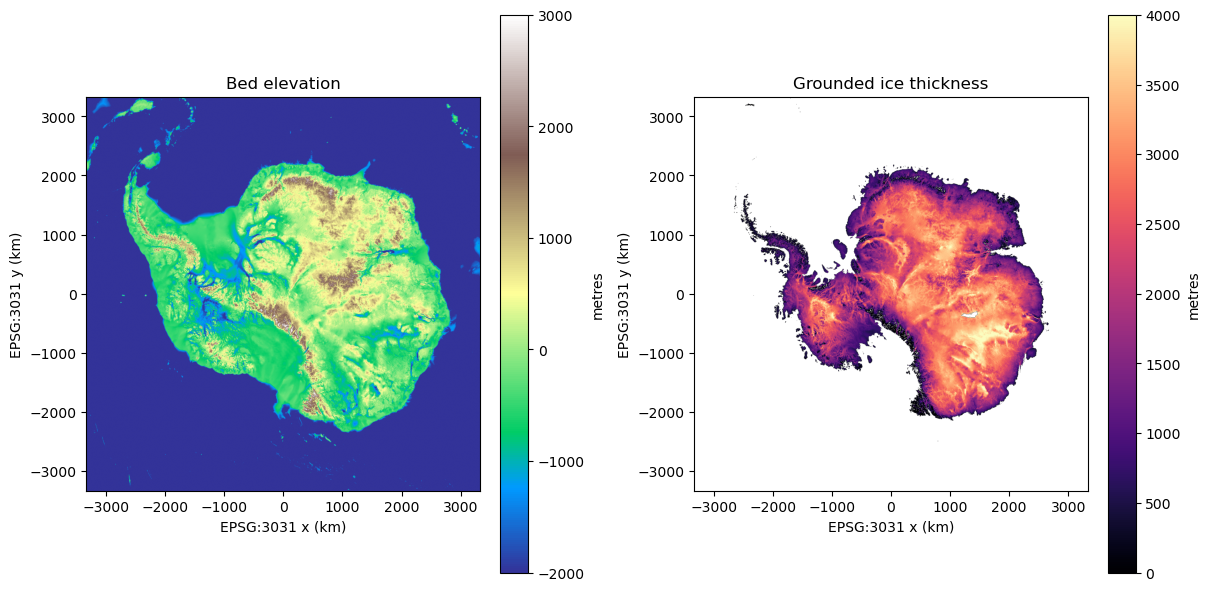

In [5]:
x_km = demo["x"].values / 1000
y_km = demo["y"].values / 1000
extent = [
    float(np.nanmin(x_km)),
    float(np.nanmax(x_km)),
    float(np.nanmin(y_km)),
    float(np.nanmax(y_km)),
]
origin = "upper" if y_km[0] > y_km[-1] else "lower"

fig, axes = plt.subplots(1, 2, figsize=(12, 5.8), constrained_layout=True)

bed_image = axes[0].imshow(
    demo["bed"].values,
    extent=extent,
    origin=origin,
    cmap="terrain",
    vmin=-2000,
    vmax=3000,
)
axes[0].set_title("Bed elevation")
axes[0].set_xlabel("EPSG:3031 x (km)")
axes[0].set_ylabel("EPSG:3031 y (km)")
fig.colorbar(bed_image, ax=axes[0], label="metres")

thickness_image = axes[1].imshow(
    demo["grounded_thickness"].values,
    extent=extent,
    origin=origin,
    cmap="magma",
    vmin=0,
    vmax=4000,
)
axes[1].set_title("Grounded ice thickness")
axes[1].set_xlabel("EPSG:3031 x (km)")
axes[1].set_ylabel("EPSG:3031 y (km)")
fig.colorbar(thickness_image, ax=axes[1], label="metres")

for ax in axes:
    ax.set_aspect("equal")

plt.show()